## Linear Regresssion
apa itu linear regression ? linear regression adalah perhitungan linear pada input terhadap bobot atau neuron (jika dalam neural network) dengan memungkinkan untuk agar hasil operasi dapat mendekati target yang di tentukan.

In [2]:
!pip install littlelearn --no-deps
import littlelearn as ll
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 2.3 MB/s eta 0:00:00


untuk hal itu bagaimana jika kita membahas dulu kenapa ini disebut sebagai aturan linear ?

In [3]:
#itu sangat sederhana ! yaitu ketika suatu perhitungan operasi memiliki hasil
#equivalen ketika antar operasi dijabarkan lebih manual
n = 10
x = 5
t = 2
r1 = n * (x + t)
r2 = n* x + n * t
print(f"r1 : {r1} || r2: {r2} mereka memiliki hasil yang sama ")
# lalu bagaimana dengan perkalian dot produt ? (karena ini adalah bagaimana neuron dalan NN bekerja)
# formula : f(x) : x . w
import random
w = []
x = [2,3,4,1]
#kita asumsikan membuat bobot acak sebagai tanda ketidaktahuan dengan bentuk (last_dim of x , dim_feature_abstraction)
for i in range(4) :
  wn = []
  for j in range(5) :
    #kita skip bagian ini, intinya disini kita mengasumsikan bahwa ini adalah bobot acak dari distribusi normal random values
    wn.append(random.normalvariate(mu=0,sigma=0.5))
  w.append(wn)
print("bobot w : ")
for i in range(4):
  print(w[i])
#dan akan kita asumsikan bahwa a * (w[0]+...w[n]) = a * w[1] +.....+ a * w[n] dan ini adalah bagaimana kita mengasumsikan bahwa
# operasi linear di dalam NN adalah bagaimana membawa informasi ke ruang dimensi yang telah di tentukan
# f(x) = x dot w
result = []
for i in range(5) :
  val = 0
  for j in range(4) :
    val += x[j] * w[j][i]
  result.append(val)
print("ini adalah bagaimana informasi di bawa ke bentuk ruang dimensi parameter ")
print(f"result : {result}" )


r1 : 70 || r2: 70 mereka memiliki hasil yang sama 
bobot w : 
[0.3387120587631653, 0.763146671832207, 0.23025941033992084, 0.7077481463159513, -0.6804904094484149]
[0.49572098362810024, -0.18099504940194, 0.057794616641661314, 0.3483408695453386, -0.7679304315298258]
[-0.6956619523651197, 0.8447139632641327, 0.299791379280894, -0.40877373107593074, -0.13941607299574124]
[0.12519545579162775, -0.3649563363829536, 0.8747932818146267, -0.39900396772794233, 0.5887119352553712]
ini adalah bagaimana informasi di bawa ke bentuk ruang dimensi parameter 
result : [-0.4928652852582198, 3.9972077121321714, 2.7078614695430283, 0.42642000923625323, -3.6337244702139]


### baiklah kita hentikan dulu teori matematis aneh ini dulu dan lansung ke praktik saja dulu.. kita ingin membuat model machine learning linear regression sederhana dahulu   

In [6]:
# aku disini menggunakan Little Learn, kalian bisa pakai Pytorch atau apapun itu jika sudah paham
# sejak awal Linear Layer hanyalah perkalian dot product saja f(x) = x dot w .. tetapi kali ini akan kubuat manual saja
# kita asumsikan bahwa perkalian x * z = n dan ingin memungkinkan bahwa model paham itu tanpa kita perlu hitung manual
from littlelearn import DeepLearning as dl
x_train = ll.rand(100,1)
y_train = x_train * 2
print(f"xample x_train : {x_train[:5]} ")
print(f"xample y_train : {y_train[:5]} ")


xample x_train : Tensor(shape=(5, 1), dtype=<class 'jax.numpy.float32'>, device=cpu, requires_grad=False)
[[0.8575988 ]
 [0.5382228 ]
 [0.09999537]
 [0.24699831]
 [0.1999321 ]]
Backwardpass class : None 
xample y_train : Tensor(shape=(5, 1), dtype=<class 'jax.numpy.float32'>, device=cpu, requires_grad=False)
[[1.7151976 ]
 [1.0764456 ]
 [0.19999075]
 [0.49399662]
 [0.3998642 ]]
Backwardpass class : None 


In [7]:
w = dl.layers.Parameter(tensor=ll.normal(mean=0,std=0.1,shape=(1,1)))
# ini untuk memungkinkan parameter menghasilkan gradient dalam engine grad soal itu nanti saja
# disini kita fokus pada praktik dulu
w.active_grad()
loss_fn = dl.loss.MSELoss()
optim = dl.optimizers.SGD(param=[w],lr=0.01)
loss_record = []
for epoch in range(1000) :
  y_pred = ll.matmul(x_train,w)
  loss= loss_fn(y_train,y_pred)
  loss.backwardpass()
  optim.step()
  loss.reset_grad()
  loss_record.append(loss.tensor)
  if epoch % 10 == 0:
    print(f"epoch : {epoch + 1} : loss : {loss.tensor}")


epoch : 1 : loss : 1.2490745782852173
epoch : 11 : loss : 1.0842362642288208
epoch : 21 : loss : 0.9411512613296509
epoch : 31 : loss : 0.8169490694999695
epoch : 41 : loss : 0.7091376185417175
epoch : 51 : loss : 0.6155537962913513
epoch : 61 : loss : 0.5343201160430908
epoch : 71 : loss : 0.46380671858787537
epoch : 81 : loss : 0.4025988280773163
epoch : 91 : loss : 0.34946852922439575
epoch : 101 : loss : 0.30334970355033875
epoch : 111 : loss : 0.2633170783519745
epoch : 121 : loss : 0.22856757044792175
epoch : 131 : loss : 0.19840389490127563
epoch : 141 : loss : 0.1722208708524704
epoch : 151 : loss : 0.14949315786361694
epoch : 161 : loss : 0.12976479530334473
epoch : 171 : loss : 0.11263991892337799
epoch : 181 : loss : 0.09777501225471497
epoch : 191 : loss : 0.08487184345722198
epoch : 201 : loss : 0.07367146015167236
epoch : 211 : loss : 0.06394919008016586
epoch : 221 : loss : 0.055509913712739944
epoch : 231 : loss : 0.0481843464076519
epoch : 241 : loss : 0.04182556644082

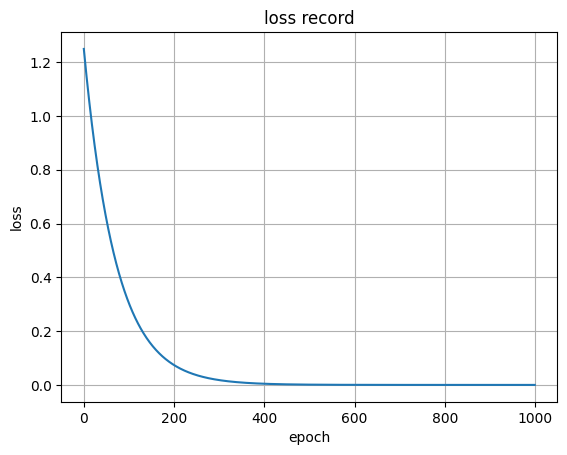

In [18]:
plt.title("loss record")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True)
plt.plot(loss_record)
plt.show()

In [14]:
#kita matikan dulu grad untuk agar tidak terjadi leak memories
# w merepresentasikan sebuah variable yang memahami angka apapun yang jika melakukan operasi linear dengannya
# maka akan menghasilkan suatu nilai mendekati n = x * 2
w.nonactive_grad()

In [16]:
pred = ll.matmul(x_train,w)
print(f"prediction : {pred[:5]}")
print(f"training data : {y_train[:5]}")
print(f"loss : {loss_fn(pred,y_train)}")

prediction : Tensor(shape=(5, 1), dtype=<class 'jax.numpy.float32'>, device=cpu, requires_grad=False)
[[1.7138342 ]
 [1.0755899 ]
 [0.19983178]
 [0.49360394]
 [0.39954636]]
Backwardpass class : None
training data : Tensor(shape=(5, 1), dtype=<class 'jax.numpy.float32'>, device=cpu, requires_grad=False)
[[1.7151976 ]
 [1.0764456 ]
 [0.19999075]
 [0.49399662]
 [0.3998642 ]]
Backwardpass class : None
loss : Tensor(shape=(), dtype=<class 'jax.numpy.float32'>, device=cpu, requires_grad=False)
8.910737960832193e-07
Backwardpass class : None
